In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
df = pd.read_parquet("../../data/iavd_incidents_raw_target.parquet")


## Блок 2. Жизненный цикл карточки инцидента

### 2.1. Перечислите значения Вердикт и частоты

In [51]:
df.value_counts("Вердикт")

Вердикт
False Positive                       150675
Не указан                             54870
Решён                                 28606
Дубликат                               5819
Не решён                                316
Закрыт по совокупности инцидентов         8
Закрыт из родительской атаки              1
Name: count, dtype: int64

In [48]:
res = df["Вердикт"].copy()
res.replace("Закрыт по совокупности инцидентов", "Закрыт по\nсовокупности\nинцидентов", inplace=True)
res.replace("Закрыт из родительской атаки", "Закрыт из\nродительской\nатаки", inplace=True)

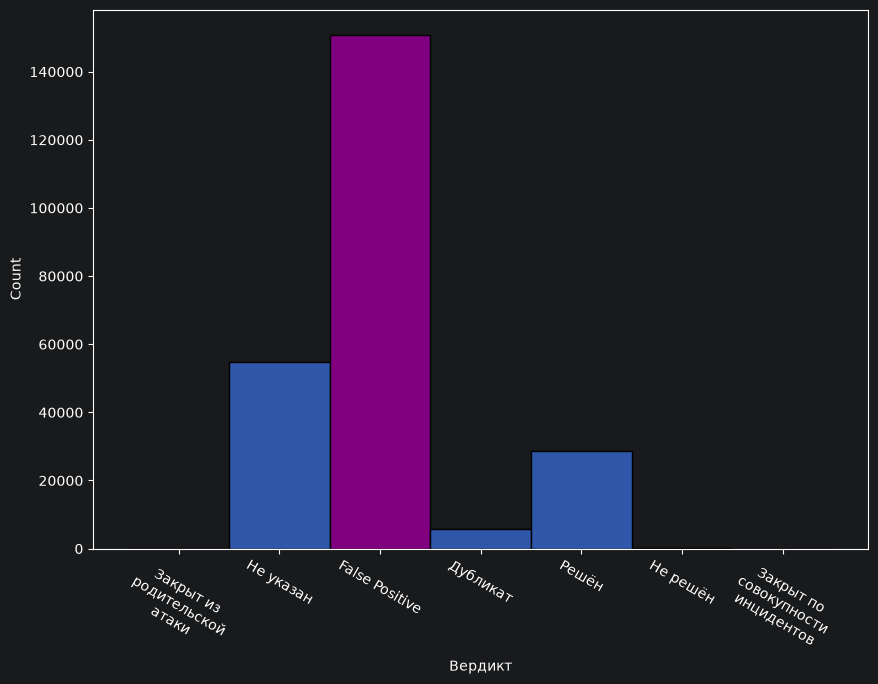

In [58]:
plt.figure(figsize=(10,7))
h = sns.histplot(res)
plt.xticks(rotation=-30)
plt.xlabel("Вердикт")
h.patches[2].set_facecolor('purple')
plt.show()

### 2.2 Доля ложных срабатываний (FP)?

In [59]:
df['Вердикт'].str.contains("False Positive", na=False).mean()


np.float64(0.6270417611685637)

### 2.3 Какие значения принимает Фаза реагирования?

In [60]:
df.value_counts("Фаза реагирования")

Фаза реагирования
Закрыт                         239557
Закрыт~~||~~Проанализирован       519
Ожидание                          103
Закрыт~~||~~Сдерживание            55
В работе                           53
Классификация~~||~~Ожидание         4
Новый                               2
В работе~~||~~Классификация         1
Устранение                          1
Name: count, dtype: int64

### 2.4 Что означают фазы вида «Закрыт~~||~~Проанализирован»?

в одной карточке сохранено несколько фаз реагирования, через которые прошёл инцидент

In [139]:
df['Фаза реагирования'].str.split(r'\~\~\|\|\~\~').explode().value_counts()

Фаза реагирования
Закрыт             240131
Проанализирован       519
Ожидание              107
Сдерживание            55
В работе               54
Классификация           5
Новый                   2
Устранение              1
Name: count, dtype: int64

### 2.5 	Самая частая комбинированная фаза?

In [91]:
t = df.value_counts("Фаза реагирования")
res = t[t.index.str.contains(r'\~\~\|\|\~\~')]
res.idxmax()

'Закрыт~~||~~Проанализирован'

### 2.6 Какие статусы карточки в источнике (SIEM)?

In [95]:
df.value_counts("Статус инцидента из SIEM")

Статус инцидента из SIEM
New         239248
Closed         842
Approved        39
Name: count, dtype: int64

### 2.7 Сколько карточек помечено как спам?

In [113]:
# df[df["Спам"]=="True"]["Спам"].count()
df[df["Спам"]=="True"].value_counts("Спам")

Спам
True    50283
Name: count, dtype: int64

### 2.8 Сколько карточек эскалировано на L2?

In [114]:
df[df["Эскалировался на L2?"]=="True"].value_counts("Эскалировался на L2?")

Эскалировался на L2?
True    1756
Name: count, dtype: int64

### 2.9 В скольких карточках выполнена проверка на FP?

In [118]:
df.value_counts("Проверка на FP выполнена", dropna=False)

Проверка на FP выполнена
False    92660
NaN      77581
True     70054
Name: count, dtype: int64

### 2.10 Согласуются ли Вердикт='False Positive' и флаг Ложное срабатывание='True'?

In [123]:
pd.crosstab(df['Вердикт'], df['Ложное срабатывание'])

Ложное срабатывание,False,True
Вердикт,,
False Positive,36,148454
Дубликат,150,50
Не решён,1,4
Не указан,5656,20261
Решён,307,128


нет, есть 36 карточек, где Вердикт='False Positive' и флаг Ложное срабатывание='True'

### 2.11 Сколько карточек «Инцидент был изменен»?

In [125]:
df["Инцидент был изменен"].value_counts()

Инцидент был изменен
True     143168
False     97007
Name: count, dtype: int64

### 2.12 Каков вердикт у карточек группы ГИБ?

In [126]:
df.groupby('Группа устранения')['Вердикт'].value_counts()

Группа устранения  Вердикт                          
L1                 False Positive                       149581
                   Не указан                             54305
                   Решён                                 27008
                   Дубликат                               5687
                   Не решён                                312
                   Закрыт по совокупности инцидентов         8
                   Закрыт из родительской атаки              1
L2                 Решён                                  1565
                   False Positive                         1058
                   Не указан                               553
                   Дубликат                                132
                   Не решён                                  4
ГИБ                Решён                                    31
                   Не указан                                12
                   False Positive                            1
Na

In [135]:
df[df['Группа устранения'] == 'ГИБ'].value_counts('Вердикт', dropna=False, normalize=True)

Вердикт
Решён             0.704545
Не указан         0.272727
False Positive    0.022727
Name: proportion, dtype: float64

доля FP всего 2,3 % — ГИБ работает с реальными инцидентами